# Notebook 41: CNN Text Classifier
**Dataset**: SMS Spam Collection | **Task**: Binary Text Classification (ham/spam)

Dataset: https://www.kaggle.com/datasets/uciml/sms-spam-collection-dataset

In [1]:
import os, warnings, re, string, pickle
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
plt.rcParams['figure.dpi'] = 100

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score
print(f"TensorFlow: {tf.__version__}")


TensorFlow: 2.20.0


In [2]:
DATA_PATH     = "/kaggle/input/datasets/organizations/uciml/sms-spam-collection-dataset"
TRAIN_FILE    = "spam.csv"
TARGET_COLUMN = "v1"
TEXT_COLUMN   = "v2"
VOCAB_SIZE    = 10000
MAX_LEN       = 100
EMBED_DIM     = 64
RANDOM_STATE  = 42
TEST_SIZE     = 0.20
MODEL_NAME    = "cnn_text"
OUTPUT_DIR    = "/kaggle/working/"

def sp(suffix):
    return os.path.join(OUTPUT_DIR, f"{MODEL_NAME}_{suffix}")

TRAIN_PATH = os.path.join(DATA_PATH, TRAIN_FILE)
print(f"Model  : {MODEL_NAME}")


Model  : cnn_text


In [3]:
try:
    df = pd.read_csv(TRAIN_PATH, encoding="latin-1")[["v1","v2"]]
    df.columns = [TARGET_COLUMN, TEXT_COLUMN]
    df.dropna(inplace=True)
    print(f"Loaded: {df.shape}")
    print(df[TARGET_COLUMN].value_counts())
except FileNotFoundError:
    print("ERROR: Add SMS Spam Collection dataset"); raise

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+", " ", text)
    text = re.sub(r"\d+", " ", text)
    text = text.translate(str.maketrans("","",string.punctuation))
    return re.sub(r"\s+", " ", text).strip()

df["clean"] = df[TEXT_COLUMN].apply(clean_text)

le = LabelEncoder()
y  = le.fit_transform(df[TARGET_COLUMN])
print(f"Classes: {dict(zip(le.classes_, le.transform(le.classes_)))}")

X_tr_raw, X_val_raw, y_tr, y_val = train_test_split(
    df["clean"].values, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y)

# Tokenize
tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token="<OOV>")
tokenizer.fit_on_texts(X_tr_raw)
X_tr  = pad_sequences(tokenizer.texts_to_sequences(X_tr_raw),  maxlen=MAX_LEN, padding="post")
X_val = pad_sequences(tokenizer.texts_to_sequences(X_val_raw), maxlen=MAX_LEN, padding="post")
print(f"X_tr: {X_tr.shape}  |  X_val: {X_val.shape}")


Loaded: (5572, 2)
v1
ham     4825
spam     747
Name: count, dtype: int64
Classes: {'ham': np.int64(0), 'spam': np.int64(1)}
X_tr: (4457, 100)  |  X_val: (1115, 100)


2026-07-11 20:05:26.859590: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "CNN_Text"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ ?                      │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 4s 30ms/step - accuracy: 0.8537 - loss: 0.4059 - val_accuracy: 0.8664 - val_loss: 0.2357
Epoch 2/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - accuracy: 0.9623 - loss: 0.1018 - val_accuracy: 0.9865 - val_loss: 0.0572
Epoch 3/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - accuracy: 0.9924 - loss: 0.0284 - val_accuracy: 0.9803 - val_loss: 0.0592
Epoch 4/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - accuracy: 0.9969 - loss: 0.0088 - val_accuracy: 0.9794 - val_loss: 0.0689
Epoch 5/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - accuracy: 0.9996 - loss: 0.0041 - val_accuracy: 0.9821 - val_loss: 0.0658
Epoch 6/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - accuracy: 0.9993 - loss: 0.0025 - val_accuracy: 0.9821 - val_loss: 0.0695
Epoch 7/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - accuracy: 0.9996 - loss: 0.0014 - val_accuracy: 0.9830 - val_loss: 0.0739


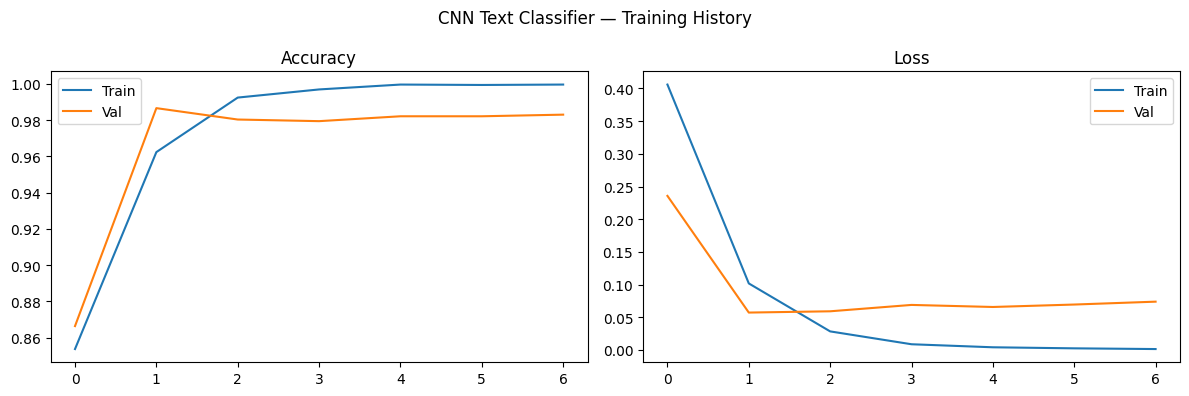

Val Accuracy: 0.9865  ROC-AUC: 0.9927
              precision    recall  f1-score   support

         ham       0.99      1.00      0.99       966
        spam       0.99      0.91      0.95       149

    accuracy                           0.99      1115
   macro avg       0.99      0.95      0.97      1115
weighted avg       0.99      0.99      0.99      1115



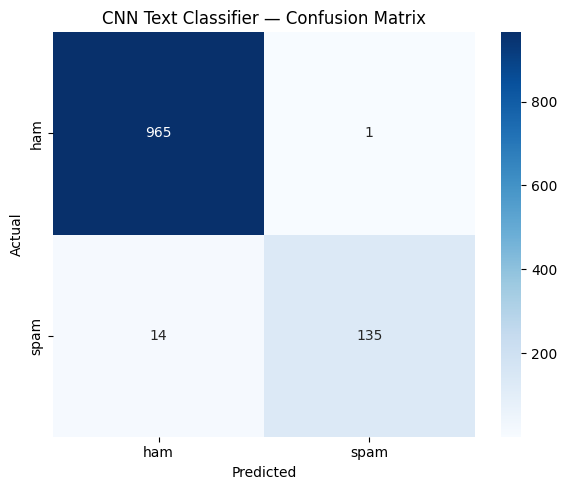

  ✓ True:ham   Pred:ham   Conf:1.000 | u coming back dinner rite dad ask me so i re confirm wif u
  ✓ True:ham   Pred:ham   Conf:0.998 | min later k
  ✓ True:spam  Pred:spam  Conf:0.994 | urgent your mobile number has been awarded with a å£ prize g
  ✓ True:ham   Pred:ham   Conf:0.996 | so check your errors and if you had difficulties do correcti
  ✓ True:ham   Pred:ham   Conf:0.999 | honestly ive just made a lovely cup of tea and promptly drop
  ✓ True:ham   Pred:ham   Conf:0.996 | crucify is c not s you should have told me earlier
  ✓ True:ham   Pred:ham   Conf:1.000 | ok i feel like john lennon
  ✓ True:spam  Pred:spam  Conf:0.978 | do you want anytime any network mins text and a new video ph
  ✓ True:ham   Pred:ham   Conf:0.998 | also track down any lighters you can find
  ✓ True:spam  Pred:spam  Conf:0.948 | congrats mobile g videophones r yours call now videochat wid


In [4]:
# ── Train & Evaluate ──────────────────────────────────────────
tf.random.set_seed(RANDOM_STATE)
model = keras.Sequential([
    layers.Embedding(VOCAB_SIZE, EMBED_DIM, input_length=MAX_LEN),
    layers.Conv1D(128, 5, activation="relu"),
    layers.GlobalMaxPooling1D(),
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(1, activation="sigmoid")
], name="CNN_Text")
model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
model.summary()


history = model.fit(X_tr, y_tr, validation_data=(X_val, y_val),
                    epochs=20, batch_size=64, verbose=1,
                    callbacks=[keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True)])

fig, axes = plt.subplots(1,2,figsize=(12,4))
axes[0].plot(history.history["accuracy"],    label="Train"); axes[0].plot(history.history["val_accuracy"],label="Val")
axes[0].set_title("Accuracy"); axes[0].legend()
axes[1].plot(history.history["loss"],    label="Train"); axes[1].plot(history.history["val_loss"],label="Val")
axes[1].set_title("Loss"); axes[1].legend()
plt.suptitle(f"CNN Text Classifier — Training History")
plt.tight_layout(); plt.savefig(sp("training_history.png"),bbox_inches="tight"); plt.show()

val_loss, val_acc = model.evaluate(X_val, y_val, verbose=0)
y_pred_prob = model.predict(X_val, verbose=0).squeeze()
y_pred_cls  = (y_pred_prob > 0.5).astype(int)
roc = roc_auc_score(y_val, y_pred_prob)
METRICS = dict(Model=MODEL_NAME, Val_Accuracy=round(val_acc,4), Val_Loss=round(val_loss,4), ROC_AUC=round(roc,4))
print(f"Val Accuracy: {val_acc:.4f}  ROC-AUC: {roc:.4f}")
print(classification_report(y_val, y_pred_cls, target_names=le.classes_, zero_division=0))

cm = confusion_matrix(y_val, y_pred_cls)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.title(f"CNN Text Classifier — Confusion Matrix")
plt.tight_layout(); plt.savefig(sp("confusion_matrix.png"),bbox_inches="tight"); plt.show()

# Sample predictions
sample_idx = np.random.choice(len(X_val), 10, replace=False)
for idx in sample_idx:
    true_lbl = le.inverse_transform([y_val[idx]])[0]
    pred_lbl = le.inverse_transform([y_pred_cls[idx]])[0]
    conf     = y_pred_prob[idx] if y_pred_cls[idx]==1 else 1-y_pred_prob[idx]
    status   = "✓" if true_lbl==pred_lbl else "✗"
    print(f"  {status} True:{true_lbl:<5} Pred:{pred_lbl:<5} Conf:{conf:.3f} | {X_val_raw[idx][:60]}")


In [5]:
import glob
model.save(sp("model.h5"))
pd.DataFrame([METRICS]).to_csv(sp("metrics.csv"), index=False)
pd.DataFrame({"y_true": y_val, "y_pred": y_pred_cls}).to_csv(sp("predictions.csv"), index=False)
with open(sp("tokenizer.pkl"), "wb") as f: pickle.dump(tokenizer, f)
for f in sorted(glob.glob(f"/kaggle/working/{MODEL_NAME}_*")): print(f"  {os.path.basename(f)}")


  cnn_text_confusion_matrix.png
  cnn_text_metrics.csv
  cnn_text_model.h5
  cnn_text_predictions.csv
  cnn_text_tokenizer.pkl
  cnn_text_training_history.png


In [6]:
print("="*60); print(f"  NOTEBOOK 41 COMPLETE — CNN TEXT CLASSIFIER"); print("="*60)
for k in ["Val_Accuracy","Val_Loss","ROC_AUC"]: print(f"  {k}: {METRICS.get(k)}")
print("="*60)


  NOTEBOOK 41 COMPLETE — CNN TEXT CLASSIFIER
  Val_Accuracy: 0.9865
  Val_Loss: 0.0572
  ROC_AUC: 0.9927
